# Example Calculation

This example demonstrates how the reliability and decision model can be run using the functions provided in `Functions.py`.

The function `run_DT_failure_model` calculates the probability of bridge failure due to scour and produces a figure highlight the capacity and demand in both the prior and posterior information cases. The function also returns several values that can be used to compute the Value of Information.

## Running the Model

The following code runs the reliability and decision model using the example dataset `WaterLevel_30Years_Q_May26.csv`. The parameters define the bridge geometry, hydraulic thresholds, and uncertainty in the capacity model.

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


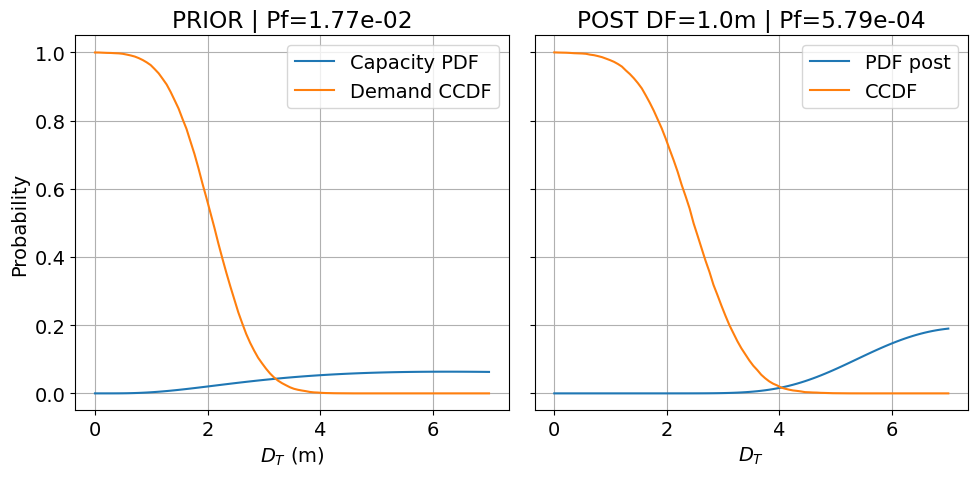

In [20]:
%load_ext autoreload
%autoreload 2

from Functions import *
import pandas as pd

DF_known=1

r, Pf_prior, E_Pf_post, P_fail_post, DF_list = run_DT_failure_model(
    waterlevel_file="WaterLevel_30Years_Q_May26.csv",
    y0=1.086,
    y200 = 2.5,
    Wp=2,
    f_PS=1,
    f_PA=1,
    f_d=1,
    bias=1.0,
    sigma_DT_error=0.3,
    mu= 8.197,
    sigma=0.277*8.197,
    DF_known=DF_known,
    DFmedian=1.349,
    sigma_ln_DF=0.703
)


## Model Output

The figure above shows the probability distributions used in the reliability analysis.

**Left panel – Prior case**

- The blue curve represents the **prior probability density function (PDF)** of the capacity $D_T$.
- The orange curve shows the **complementary cumulative distribution function (CCDF)**, which represents the probability that the demand exceeds the capacity.
- The resulting **prior probability of failure** is $P_f = 1.75 \times 10^{-1}$.

**Right panel – Posterior case**

- The foundation depth is assumed to be **known** (in this example $D_F$ = 1.0 m).
- The blue curve now represents the **posterior distribution** conditioned on this information.
- The CCDF again represents the exceedance probability used to compute the **posterior probability of failure**.

This comparison illustrates how knowledge of the true foundation depth influences the reliability estimate and forms the basis for the **Value of Information** ($\textit{VoI}$) calculation.

## Printing Key Results

The following code prints the calculated results from the model, including:

- Prior probability of failure
- Posterior probabilities of failure
- Expected utilities (costs)
- Value of Information

In [19]:
items = list(r.items())

print("Prior")
print("-" * 30)
for k, v in items[:5]:
    print(f"{k:<22} : {v:.5f}" if isinstance(v, float) else f"{k:<22} : {v}")

print("\nPosterior")
print("-" * 30)
for k, v in items[5:10]:
    print(f"{k:<22} : {v:.5f}" if isinstance(v, float) else f"{k:<22} : {v}")

print("\nVoI")
print("-" * 30)

# second last item (normal formatting)
k, v = items[10]
print(f"{k:<22} : {v:.5f}" if isinstance(v, float) else f"{k:<22} : {v}")

# last item (0 decimal places)
k, v = items[11]
print(f"{k:<22} : {v:.0f}" if isinstance(v, float) else f"{k:<22} : {v}")

Prior
------------------------------
Pf_prior               : 0.01768
EC_M                   : 1.63174
EC_DN_prior            : 1.59667
EC_RR_prior            : 0.04000
EC_prior               : 0.04000

Posterior
------------------------------
Expected_Pf_Post       : 0.01775
EC_pp                  : 0.01364
Number of optimal DN   : 14034
Number of optimal M    : 0
Number of optimal RR   : 5966

VoI
------------------------------
VoI                    : 0.02636
VoI £                  : 52711
